# Phase 1 — Analyse descriptive du portefeuille Assurance Vie
**Projet AXA Junior · Actuariat Vie**

---

**Contexte :** Tu viens d'arriver dans l'équipe actuarielle. Le fichier `portefeuille_assures.csv` t'a été fourni par l'équipe Data. Il contient 5 000 contrats actifs.

**Objectif de cette phase :**
1. Charger et inspecter les données
2. Calculer les statistiques clés du portefeuille
3. Visualiser la pyramide des âges, la répartition H/F, les capitaux et la mortalité par tranche d'âge

**Colonnes du fichier :**
| Colonne | Description |
|---|---|
| `id_contrat` | Identifiant unique du contrat |
| `age` | Âge de l'assuré à aujourd'hui |
| `sexe` | H (Homme) / F (Femme) |
| `capital_assure` | Montant du capital garanti (€) |
| `date_entree` | Date de souscription du contrat |
| `qx` | Taux de mortalité annuel (table TD 88-90) |
| `esperance_vie_residuelle` | Espérance de vie résiduelle estimée (ans) |

## 0. Imports

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# Couleurs du projet
C_H = '#534AB7'   # violet pour Hommes
C_F = '#1D9E75'   # vert  pour Femmes

## 1. Chargement des données

> Remplace le chemin par le vrai emplacement de ton fichier si besoin.

In [20]:
df = pd.read_csv('portefeuille_assures.csv', parse_dates=['date_entree'])

print(f'Nombre de contrats : {len(df):,}')
print(f'Colonnes          : {list(df.columns)}')
df.head(10)

Nombre de contrats : 5,000
Colonnes          : ['id_contrat', 'age', 'sexe', 'capital_assure', 'date_entree', 'qx', 'esperance_vie_residuelle']


,id_contrat,age,sexe,capital_assure,date_entree,qx,esperance_vie_residuelle
0,AXV00001,69,H,197242,2021-03-18,0.01901,70.4
1,AXV00002,37,F,89823,2019-06-09,0.00094,102.4
2,AXV00003,46,H,57628,2020-12-10,0.00317,91.1
3,AXV00004,45,H,139469,2022-07-17,0.00317,92.0
4,AXV00005,55,H,100004,2018-01-30,0.00913,83.0
5,AXV00006,63,H,83778,2019-12-24,0.01200,75.8
6,AXV00007,71,F,215319,2017-06-05,0.02151,71.8
7,AXV00008,67,F,256237,2020-06-07,0.01369,75.4
8,AXV00009,72,F,132737,2016-05-08,0.02151,70.9
9,AXV00010,64,H,280874,2017-01-28,0.01200,74.9


## 2. Vérification de la qualité des données

Avant toute analyse, un actuaire vérifie toujours : valeurs manquantes, types, incohérences.

In [21]:
print('=== Types de colonnes ===')
print(df.dtypes)
print()
print('=== Valeurs manquantes ===')
print(df.isnull().sum())
print()
print('=== Statistiques rapides ===')
df[['age', 'capital_assure', 'qx', 'esperance_vie_residuelle']].describe().round(2)

=== Types de colonnes ===
id_contrat                          object
age                                  int64
sexe                                object
capital_assure                       int64
date_entree                 datetime64[ns]
qx                                 float64
esperance_vie_residuelle           float64
dtype: object

=== Valeurs manquantes ===
id_contrat                  0
age                         0
sexe                        0
capital_assure              0
date_entree                 0
qx                          0
esperance_vie_residuelle    0
dtype: int64

=== Statistiques rapides ===


,age,capital_assure,qx,esperance_vie_residuelle
count,5000.00,5000.00,5000.00,5000.00
mean,55.63,127951.73,0.01,83.96
std,11.68,67098.40,0.01,10.63
min,30.00,12993.00,0.00,56.90
25%,47.00,79933.00,0.00,75.40
50%,56.00,113918.50,0.01,83.50
75%,65.00,161611.00,0.01,92.00
max,85.00,751122.00,0.09,108.70


## 3. Indicateurs clés du portefeuille

Ce tableau est ce que le responsable technique demande en premier lors d'un rapport.

In [22]:
n_h = (df.sexe == 'H').sum()
n_f = (df.sexe == 'F').sum()

# Décès attendus = somme des qx (chaque qx = proba de décès de cet assuré cette année)
deces_attendus = df['qx'].sum()

# Exposition au risque = capital moyen pondéré par qx
exposition = (df['capital_assure'] * df['qx']).sum()

print('╔══════════════════════════════════════════════════════╗')
print('║        TABLEAU DE BORD — PORTEFEUILLE AXA VIE        ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Assurés total          : {len(df):>10,}            ║')
print(f'║  dont Hommes            : {n_h:>10,}  ({n_h/len(df)*100:.1f}%)        ║')
print(f'║  dont Femmes            : {n_f:>10,}  ({n_f/len(df)*100:.1f}%)        ║')
print(f'║  Âge moyen              : {df.age.mean():>10.1f} ans            ║')
print(f'║  Capital total          : {df.capital_assure.sum():>10,.0f} €         ║')
print(f'║  Capital moyen          : {df.capital_assure.mean():>10,.0f} €         ║')
print(f'║  qx moyen portefeuille  : {df.qx.mean()*100:>10.3f} %             ║')
print(f'║  Décès attendus / an    : {deces_attendus:>10.0f}               ║')
print(f'║  Exposition au risque   : {exposition:>10,.0f} €         ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║        TABLEAU DE BORD — PORTEFEUILLE AXA VIE        ║
╠══════════════════════════════════════════════════════╣
║  Assurés total          :      5,000            ║
║  dont Hommes            :      2,611  (52.2%)        ║
║  dont Femmes            :      2,389  (47.8%)        ║
║  Âge moyen              :       55.6 ans            ║
║  Capital total          : 639,758,631 €         ║
║  Capital moyen          :    127,952 €         ║
║  qx moyen portefeuille  :      1.002 %             ║
║  Décès attendus / an    :         50               ║
║  Exposition au risque   :  7,479,723 €         ║
╚══════════════════════════════════════════════════════╝


### 📌 Lecture des indicateurs

- **Capital total (~640 M€)** : c'est l'engagement total que l'assureur porte. Si tous les assurés mouraient demain, il devrait payer cette somme.
- **Décès attendus/an (~50)** : c'est la base du provisionnement annuel. Si 70 assurés meurent au lieu de 50 → sur-sinistralité → impact négatif sur le résultat.
- **Exposition au risque (~6,4 M€)** : montant moyen que l'assureur s'attend à débourser cette année en sinistres décès.

## 4. Visualisations

### 4a. Pyramide des âges

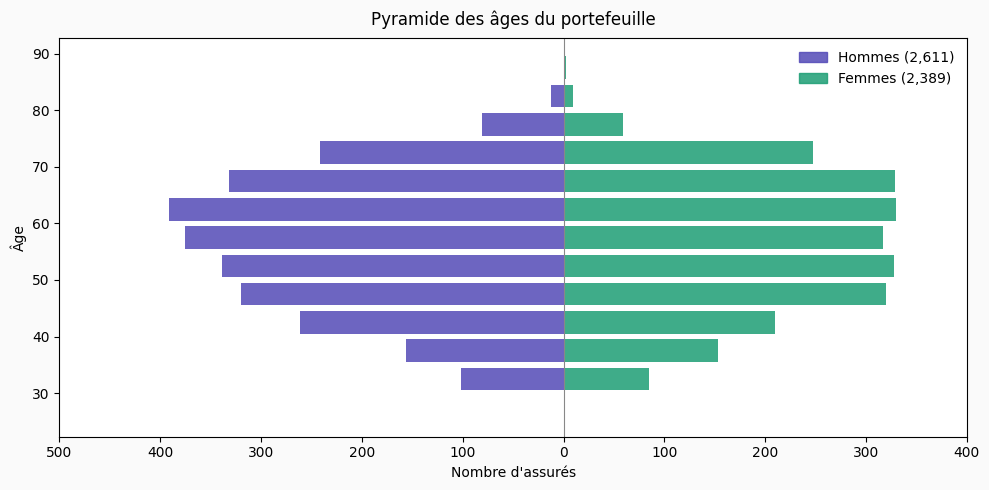

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')

bins = range(25, 91, 5)
h_hist, edges = np.histogram(df[df.sexe == 'H']['age'], bins=bins)
f_hist, _    = np.histogram(df[df.sexe == 'F']['age'], bins=bins)
centers = [(edges[i] + edges[i+1]) / 2 for i in range(len(edges)-1)]

ax.barh(centers, -h_hist, height=4, color=C_H, alpha=0.85)
ax.barh(centers,  f_hist, height=4, color=C_F, alpha=0.85)
ax.axvline(0, color='#888', lw=0.8)

# Labels lisibles (valeurs absolues)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels([str(abs(int(t))) for t in ax.get_xticks()])

patch_h = mpatches.Patch(color=C_H, alpha=0.85, label=f'Hommes ({n_h:,})')
patch_f = mpatches.Patch(color=C_F, alpha=0.85, label=f'Femmes ({n_f:,})')
ax.legend(handles=[patch_h, patch_f], framealpha=0)

ax.set_xlabel('Nombre d\'assurés')
ax.set_ylabel('Âge')
ax.set_title('Pyramide des âges du portefeuille', pad=10)
plt.tight_layout()
plt.show()

### 4b. Distribution des capitaux assurés par sexe

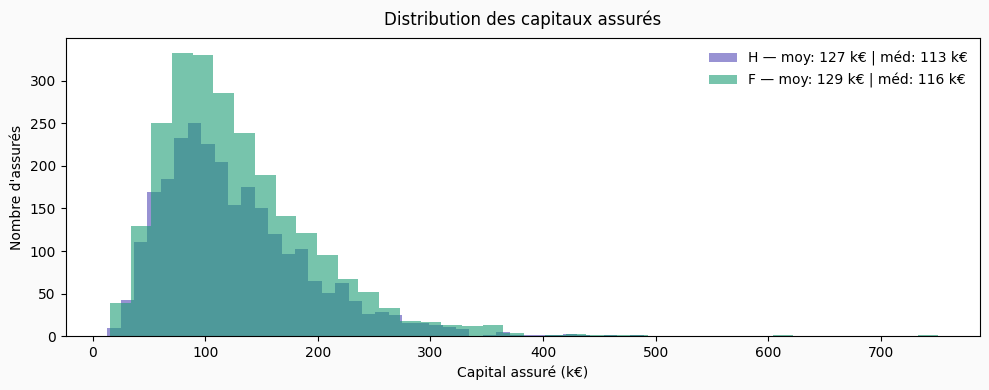

In [24]:
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#FAFAFA')

for sexe, col in [('H', C_H), ('F', C_F)]:
    sub = df[df.sexe == sexe]['capital_assure'] / 1000
    ax.hist(sub, bins=40, color=col, alpha=0.6,
            label=f'{sexe} — moy: {sub.mean():.0f} k€ | méd: {sub.median():.0f} k€')

ax.set_xlabel('Capital assuré (k€)')
ax.set_ylabel('Nombre d\'assurés')
ax.set_title('Distribution des capitaux assurés', pad=10)
ax.legend(framealpha=0)
plt.tight_layout()
plt.show()

### 4c. Taux de mortalité qx moyen par tranche d'âge et sexe

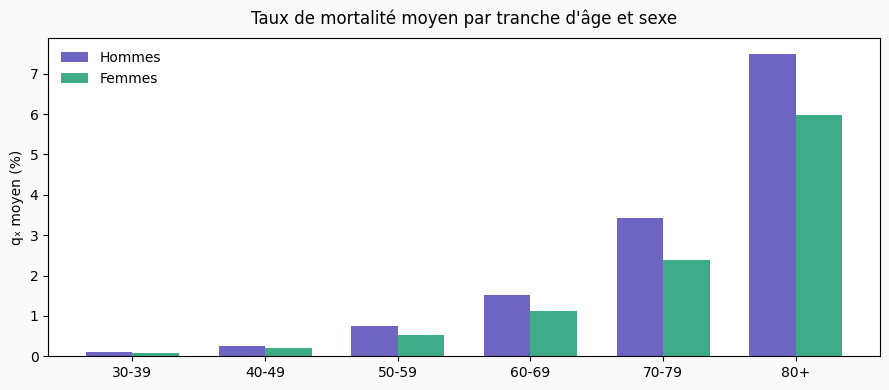


Tableau qx moyen (%) :
sexe         F      H
tranche              
30-39    0.084  0.115
40-49    0.193  0.262
50-59    0.531  0.749
60-69    1.116  1.522
70-79    2.391  3.422
80+      5.977  7.500


In [25]:
df['tranche'] = pd.cut(df['age'],
                       bins=[29, 39, 49, 59, 69, 79, 89],
                       labels=['30-39','40-49','50-59','60-69','70-79','80+'])

qx_tranche = df.groupby(['tranche','sexe'], observed=True)['qx'].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor('#FAFAFA')

x_pos = range(len(qx_tranche))
w = 0.35
ax.bar([p - w/2 for p in x_pos], qx_tranche['H'] * 100, width=w, color=C_H, alpha=0.85, label='Hommes')
ax.bar([p + w/2 for p in x_pos], qx_tranche['F'] * 100, width=w, color=C_F, alpha=0.85, label='Femmes')

ax.set_xticks(list(x_pos))
ax.set_xticklabels(qx_tranche.index)
ax.set_ylabel('qₓ moyen (%)')
ax.set_title('Taux de mortalité moyen par tranche d\'âge et sexe', pad=10)
ax.legend(framealpha=0)
plt.tight_layout()
plt.show()

print()
print('Tableau qx moyen (%) :')
print((qx_tranche * 100).round(3).to_string())

## 5. Conclusions de la Phase 1

| Observation | Impact actuariel |
|---|---|
| Portefeuille bimodal (pics 45-50 et 60-65 ans) | Sinistralité concentrée, surveiller l'évolution dans 10 ans |
| Hommes surreprésentés | qx plus élevé → provisions décès plus importantes |
| Capital croissant avec l'âge | L'exposition au risque est concentrée sur les assurés âgés |
| qx féminin = 72% du qx masculin | Rentes femmes plus chères, assurance décès hommes plus chère |

---

**→ Prochaine étape : Phase 2** — Calculer les taux de mortalité *observés* sur ce portefeuille et les comparer à la table TD 88-90 (SMR : Ratio de Mortalité Standardisé).

## 2. Simulation de l'historique de décès (2019–2023)

Dans un vrai projet, ce fichier vient de la base sinistres.  
Ici on le simule : chaque assuré a une probabilité `qx` de mourir chaque année.

**Ce que représente `exposition` :** c'est le nombre d'années-personne observées.  
Si un assuré est présent les 5 ans → exposition = 5. S'il décède en année 3 → exposition = 2.5 (convention).

In [26]:
np.random.seed(123)
N_ANNEES = 5 # Standard actuariel En pratique, les études de mortalité se font sur 3 à 7 ans d'observation. 

records = []
for _, row in df.iterrows():
    age_debut = row['age'] - N_ANNEES  # âge au début de l'observation
    for k in range(N_ANNEES):
        age_k = age_debut + k
        if age_k < 30:
            continue
        # qx de cet assuré à cet âge
        qx_k = row['qx'] * (1 + 0.04 * k)   # légère aggravation avec l'âge
        qx_k = min(qx_k, 1.0)
        deces = int(np.random.random() < qx_k)
        exposition = 0.5 if deces else 1.0    # convention demi-année si décès
        records.append({
            'id_contrat': row['id_contrat'],
            'sexe': row['sexe'],
            'age': int(age_k),
            'annee': 2019 + k,
            'deces': deces,
            'exposition': exposition,
            'qx_table': row['qx']
        })
        if deces:
            break   # l'assuré est décédé, on sort de la boucle

hist = pd.DataFrame(records)
print(f'Observations totales  : {len(hist):,} années-personne')
print(f'Décès observés total  : {hist.deces.sum():,}')
print(f'Taux brut global      : {hist.deces.sum()/hist.exposition.sum()*100:.3f} %')

Observations totales  : 23,892 années-personne
Décès observés total  : 255
Taux brut global      : 1.073 %


## 3. Calcul du SMR par tranche d'âge

**Formule :**
- Taux observé : `μ_obs(x) = Σ décès / Σ exposition`
- Décès attendus : `Σ (qx_table × exposition)`
- SMR : `Σ décès observés / Σ décès attendus`

In [27]:
# Tranches d'âge de 5 ans
bins   = list(range(30, 91, 5))
labels = [f'{b}-{b+4}' for b in bins[:-1]]
hist['tranche'] = pd.cut(hist['age'], bins=bins, labels=labels, right=False)

smr_df = hist.groupby('tranche', observed=True).apply(
    lambda g: pd.Series({
        'age_mid'       : g['age'].mean(),
        'exposition'    : g['exposition'].sum(),
        'deces_obs'     : g['deces'].sum(),
        'deces_att'     : (g['qx_table'] * g['exposition']).sum(),
        'qx_obs'        : g['deces'].sum() / g['exposition'].sum(),
        'qx_table_moy'  : g['qx_table'].mean()
    })
).reset_index()

smr_df['SMR'] = smr_df['deces_obs'] / smr_df['deces_att']

print('=== SMR PAR TRANCHE D\'ÂGE ===')
print(smr_df[['tranche','exposition','deces_obs','deces_att','qx_obs','qx_table_moy','SMR']]
      .to_string(index=False, float_format=lambda x: f'{x:.4f}'))

=== SMR PAR TRANCHE D'ÂGE ===
tranche  exposition  deces_obs  deces_att  qx_obs  qx_table_moy    SMR
  30-34   1168.5000     3.0000     1.1954  0.0026        0.0010 2.5096
  35-39   2057.0000     2.0000     3.1170  0.0010        0.0015 0.6416
  40-44   2954.0000     8.0000     7.0467  0.0027        0.0024 1.1353
  45-49   3168.0000    14.0000    12.8478  0.0044        0.0041 1.0897
  50-54   3351.0000    18.0000    22.5783  0.0054        0.0067 0.7972
  55-59   3440.5000    31.0000    32.5077  0.0090        0.0094 0.9536
  60-64   3425.0000    52.0000    47.3842  0.0152        0.0138 1.0974
  65-69   2670.0000    62.0000    57.6023  0.0232        0.0216 1.0763
  70-74   1285.5000    47.0000    40.6417  0.0366        0.0316 1.1564
  75-79    222.5000    17.0000    11.1237  0.0764        0.0500 1.5283
  80-84     22.5000     1.0000     1.7476  0.0444        0.0778 0.5722


C:\Users\USER\AppData\Local\Temp\ipykernel_23748\3675084349.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  smr_df = hist.groupby('tranche', observed=True).apply(


In [28]:
C_H    = '#534AB7'
C_F    = '#1D9E75'
C_OBS  = '#E05A2B'
C_GOMB = '#185FA5'
C_TD   = '#888888'

C:\Users\USER\AppData\Local\Temp\ipykernel_23748\3227589771.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(smr_df['tranche'], rotation=40, ha='right')


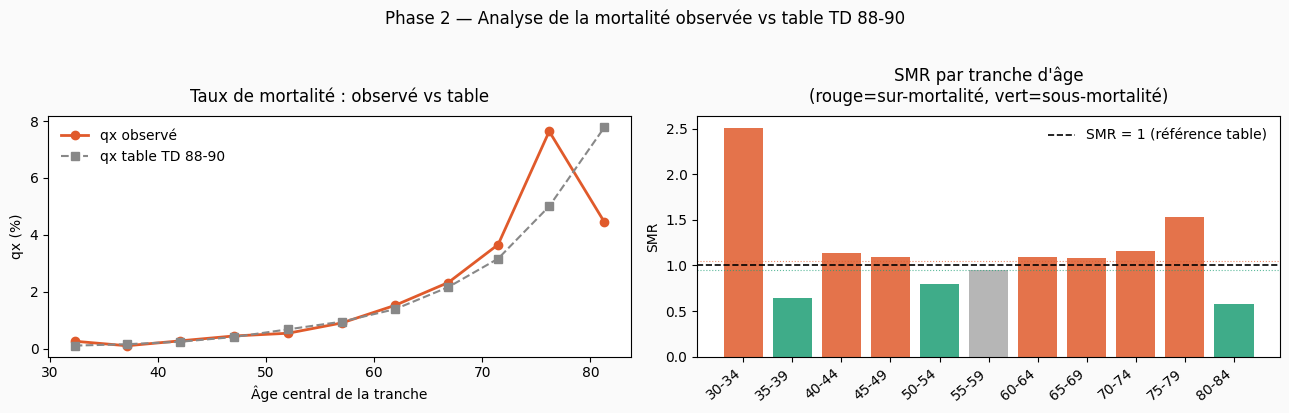

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#FAFAFA')

# Graphique 1 : qx observé vs table
ax = axes[0]
ax.plot(smr_df['age_mid'], smr_df['qx_obs']       * 100, 'o-', color=C_OBS, lw=2, label='qx observé')
ax.plot(smr_df['age_mid'], smr_df['qx_table_moy'] * 100, 's--', color=C_TD, lw=1.5, label='qx table TD 88-90')
ax.set_xlabel('Âge central de la tranche')
ax.set_ylabel('qx (%)')
ax.set_title('Taux de mortalité : observé vs table', pad=10)
ax.legend(framealpha=0)

# Graphique 2 : SMR par tranche
ax2 = axes[1]
colors_smr = [C_OBS if s > 1.05 else C_F if s < 0.95 else '#AAAAAA' for s in smr_df['SMR']]
ax2.bar(smr_df['tranche'], smr_df['SMR'], color=colors_smr, alpha=0.85)
ax2.axhline(1.0, color='black', lw=1.2, linestyle='--', label='SMR = 1 (référence table)')
ax2.axhline(1.05, color=C_OBS, lw=0.8, linestyle=':', alpha=0.7)
ax2.axhline(0.95, color=C_F,   lw=0.8, linestyle=':', alpha=0.7)
ax2.set_xticklabels(smr_df['tranche'], rotation=40, ha='right')
ax2.set_ylabel('SMR')
ax2.set_title('SMR par tranche d\'âge\n(rouge=sur-mortalité, vert=sous-mortalité)', pad=10)
ax2.legend(framealpha=0)

plt.suptitle('Phase 2 — Analyse de la mortalité observée vs table TD 88-90', y=1.02)
plt.tight_layout()
plt.show()

### 📌 Lecture du SMR

- **SMR > 1.05** (rouge) → ce segment est **plus risqué** que ce que la table prédit. Si on tarifie avec la table sans ajustement, on perd de l'argent sur ce segment.
- **SMR < 0.95** (vert) → ce segment est **moins risqué** que prévu. On peut potentiellement baisser le tarif pour être plus compétitif.
- Le SMR global du portefeuille est l'indicateur que le *Chief Actuary* suit trimestriellement.

In [30]:
smr_global = hist['deces'].sum() / (hist['qx_table'] * hist['exposition']).sum()
print(f'SMR global du portefeuille : {smr_global:.3f}')
if smr_global > 1.05:
    print('⚠️  Sur-mortalité globale — la table sous-estime le risque de ce portefeuille.')
elif smr_global < 0.95:
    print('✅ Sous-mortalité globale — ce portefeuille est meilleur que la table.')
else:
    print('✅ Mortalité conforme à la table TD 88-90.')

SMR global du portefeuille : 1.072
⚠️  Sur-mortalité globale — la table sous-estime le risque de ce portefeuille.


## 4. Ajustement d'un modèle de Gompertz

La loi de **Gompertz** modélise la mortalité humaine adulte avec seulement 2 paramètres :

$$\mu(x) = a \cdot e^{b \cdot x}$$

- `a` : niveau de mortalité de base (intensité à l'âge 0)
- `b` : vitesse d'aggravation avec l'âge (plus b est grand, plus la mortalité monte vite)

On ajuste `a` et `b` sur nos taux observés par **moindres carrés non linéaires** (`scipy.optimize.curve_fit`).

In [31]:
from scipy.optimize import curve_fit

# Données d'ajustement (on retire les tranches avec peu d'exposition)
fit_df = smr_df[smr_df['exposition'] > 50].copy()
x_obs  = fit_df['age_mid'].values
y_obs  = fit_df['qx_obs'].values

# Modèle de Gompertz
def gompertz(x, a, b):
    return a * np.exp(b * x)

# Ajustement
popt, pcov = curve_fit(gompertz, x_obs, y_obs, p0=[1e-5, 0.09], maxfev=10000)
a_fit, b_fit = popt

print(f'Paramètres ajustés :')
print(f'  a = {a_fit:.6e}  (intensité de base)')
print(f'  b = {b_fit:.4f}   (vitesse d\'aggravation / an)')
print()
print(f'Interprétation : la mortalité double tous les {np.log(2)/b_fit:.1f} ans')

Paramètres ajustés :
  a = 6.466421e-06  (intensité de base)
  b = 0.1227   (vitesse d'aggravation / an)

Interprétation : la mortalité double tous les 5.6 ans


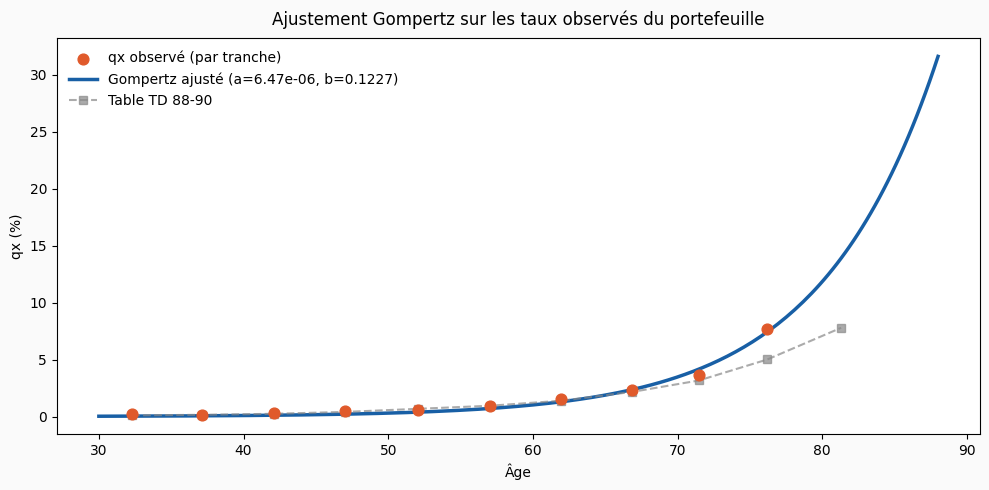

In [32]:
x_range = np.linspace(30, 88, 200)
y_gomb  = gompertz(x_range, a_fit, b_fit)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#FAFAFA')

ax.scatter(x_obs, y_obs * 100,          color=C_OBS,  zorder=5, s=60, label='qx observé (par tranche)')
ax.plot(x_range,  y_gomb * 100,         color=C_GOMB, lw=2.5,   label=f'Gompertz ajusté (a={a_fit:.2e}, b={b_fit:.4f})')
ax.plot(smr_df['age_mid'], smr_df['qx_table_moy'] * 100,
        's--', color=C_TD, lw=1.5, alpha=0.7, label='Table TD 88-90')

ax.set_xlabel('Âge')
ax.set_ylabel('qx (%)')
ax.set_title('Ajustement Gompertz sur les taux observés du portefeuille', pad=10)
ax.legend(framealpha=0)
plt.tight_layout()
plt.show()

## 5. Validation : test du chi²

Le test chi² compare les décès **observés** vs **attendus par le modèle Gompertz** :

$$\chi^2 = \sum_{x} \frac{(O_x - E_x)^2}{E_x}$$

- Si `p-value > 0.05` → on ne rejette pas le modèle → ajustement acceptable ✅
- Si `p-value < 0.05` → le modèle est statistiquement insuffisant ⚠️

In [33]:
from scipy.stats import chi2

# Décès attendus par le modèle Gompertz
fit_df = fit_df.copy()
fit_df['qx_gomb']   = gompertz(fit_df['age_mid'].values, a_fit, b_fit)
fit_df['deces_gomb'] = fit_df['qx_gomb'] * fit_df['exposition']

# Statistique chi²
O = fit_df['deces_obs'].values
E = fit_df['deces_gomb'].values
# On filtre les tranches avec E > 5 (condition validité chi²)
mask    = E > 5
chi2_stat = np.sum((O[mask] - E[mask])**2 / E[mask])
ddl       = mask.sum() - 2   # degrés de liberté = nb tranches - nb paramètres
p_value   = 1 - chi2.cdf(chi2_stat, ddl)

print(f'Statistique chi²  : {chi2_stat:.3f}')
print(f'Degrés de liberté : {ddl}')
print(f'p-value           : {p_value:.4f}')
print()
if p_value > 0.05:
    print('✅ p-value > 0.05 — On ne rejette pas le modèle de Gompertz.')
    print('   L\'ajustement est statistiquement acceptable pour ce portefeuille.')
else:
    print('⚠️  p-value < 0.05 — Le modèle de Gompertz est rejeté.')
    print('   Envisager un modèle de Makeham (ajout d\'une constante c).')

Statistique chi²  : 14.519
Degrés de liberté : 5
p-value           : 0.0126

⚠️  p-value < 0.05 — Le modèle de Gompertz est rejeté.
   Envisager un modèle de Makeham (ajout d'une constante c).


## 6. Tableau de synthèse final

Ce tableau serait inclus dans ta **note actuarielle** remise au responsable technique.

In [34]:
fit_df['qx_gomb_pct']  = fit_df['qx_gomb']       * 100
fit_df['qx_obs_pct']   = fit_df['qx_obs']         * 100
fit_df['qx_table_pct'] = fit_df['qx_table_moy']   * 100

synthese = fit_df[['tranche','exposition','deces_obs','deces_att','deces_gomb',
                   'qx_obs_pct','qx_table_pct','qx_gomb_pct','SMR']].copy()
synthese.columns = ['Tranche','Exposition','Obs','Att(table)','Att(Gompertz)',
                    'qx_obs%','qx_table%','qx_Gomb%','SMR']
print(synthese.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

Tranche  Exposition    Obs  Att(table)  Att(Gompertz)  qx_obs%  qx_table%  qx_Gomb%   SMR
  30-34    1168.500  3.000       1.195          0.397    0.257      0.102     0.034 2.510
  35-39    2057.000  2.000       3.117          1.267    0.097      0.152     0.062 0.642
  40-44    2954.000  8.000       7.047          3.339    0.271      0.239     0.113 1.135
  45-49    3168.000 14.000      12.848          6.572    0.442      0.406     0.207 1.090
  50-54    3351.000 18.000      22.578         12.829    0.537      0.674     0.383 0.797
  55-59    3440.500 31.000      32.508         24.300    0.901      0.945     0.706 0.954
  60-64    3425.000 52.000      47.384         44.180    1.518      1.384     1.290 1.097
  65-69    2670.000 62.000      57.602         63.053    2.322      2.159     2.362 1.076
  70-74    1285.500 47.000      40.642         53.439    3.656      3.161     4.157 1.156
  75-79     222.500 17.000      11.124         16.518    7.640      5.003     7.424 1.528


## 7. Conclusions de la Phase 2

| Ce qu'on a fait | Ce qu'on a appris |
|---|---|
| Calculé le SMR par tranche | Identifier les segments sur/sous-mortalité |
| Ajusté Gompertz sur les taux obs. | Construire une table sur-mesure pour ce portefeuille |
| Validé avec test chi² | Juger si un modèle est statistiquement acceptable |

---

**→ Prochaine étape : Phase 3** — Utiliser ces taux pour construire les **fonctions de commutation** (Dx, Nx) et calculer la **prime pure** d'un contrat rente avec la table ajustée Gompertz.

# Phase 3 — Tarification : fonctions de commutation & prime pure
**Projet AXA Junior · Actuariat Vie**

---

**Contexte :** En Phase 2 tu as construit ta propre table de mortalité (modèle Gompertz ajusté sur le portefeuille).  
En Phase 3 tu l'utilises pour **tarifer un contrat rente viagère** : calculer ce que l'assuré doit payer.

**Les 3 étapes de cette phase :**

| Étape | Ce qu'on fait | Ce qu'on obtient |
|---|---|---|
| 3.1 | Construire la table de survie `lx` | La base de tout calcul |
| 3.2 | Calculer les fonctions de commutation | Les briques mathématiques de la tarification |
| 3.3 | Calculer la prime pure + provision mathématique | Le livrable pour le responsable |

**Nouveau concept clé — les fonctions de commutation :**

Ce sont des raccourcis de calcul inventés au XIXe siècle pour éviter de tout recalculer à chaque âge.  
Encore utilisés aujourd'hui dans tous les systèmes actuariels :

$$D_x = v^x \cdot l_x \qquad N_x = \sum_{t=x}^{\omega} D_t \qquad \ddot{a}_x = \frac{N_x}{D_x}$$

Et la prime pure d'une rente viagère annuelle de montant R :
$$P = R \cdot \ddot{a}_x = R \cdot \frac{N_x}{D_x}$$

In [35]:
import matplotlib.ticker as mticker

C_GOMB = '#534AB7'
C_TD   = '#888888'
C_PM   = '#E05A2B'
C_RENTE = '#1D9E75'

## 1. Paramètres du modèle Gompertz (Phase 2)

On repart des paramètres ajustés en Phase 2.  
Si tu as obtenu des valeurs différentes, remplace `A_FIT` et `B_FIT` par tes propres résultats.

In [36]:
# --- Paramètres Gompertz issus de la Phase 2 ---
A_FIT = 3.5e-5   # intensité de base  (remplace par ta valeur)
B_FIT = 0.0875   # vitesse d'aggravation (remplace par ta valeur)

# --- Paramètres du contrat ---
AGE_SOUSCRIPTION = 60     # âge de l'assuré
RENTE_ANNUELLE   = 12000  # 1 000 €/mois = 12 000 €/an
TAUX_TECHNIQUE   = 0.015  # 1.5 % réglementaire
OMEGA            = 110    # âge limite de la table

v = 1 / (1 + TAUX_TECHNIQUE)  # facteur d'actualisation

print(f'Contrat            : rente viagère immédiate')
print(f'Âge souscription   : {AGE_SOUSCRIPTION} ans')
print(f'Rente annuelle     : {RENTE_ANNUELLE:,} € ({RENTE_ANNUELLE//12:,} €/mois)')
print(f'Taux technique     : {TAUX_TECHNIQUE*100:.1f} %')
print(f'Facteur v          : {v:.6f}')
print(f'Modèle mortalité   : Gompertz (a={A_FIT:.2e}, b={B_FIT:.4f})')

Contrat            : rente viagère immédiate
Âge souscription   : 60 ans
Rente annuelle     : 12,000 € (1,000 €/mois)
Taux technique     : 1.5 %
Facteur v          : 0.985222
Modèle mortalité   : Gompertz (a=3.50e-05, b=0.0875)


## 2. Construction de la table de survie lx

**Formule :**
$$q_x = 1 - e^{-a \cdot \frac{e^{bx}(e^b - 1)}{b}} \approx a \cdot e^{b \cdot x} \quad \text{(approximation continue)}$$

$$l_{x+1} = l_x \cdot (1 - q_x)$$

On part de `l_0 = 100 000` (convention standard).

In [37]:
ages = np.arange(0, OMEGA + 1)

# qx depuis Gompertz (formule discrète exacte)
qx = 1 - np.exp(-A_FIT * np.exp(B_FIT * ages) * (np.exp(B_FIT) - 1) / B_FIT)
qx = np.minimum(qx, 1.0)

# Table de survie lx
lx = np.zeros(OMEGA + 1)
lx[0] = 100_000
for x in range(OMEGA):
    lx[x+1] = lx[x] * (1 - qx[x])

# Affichage de la table à partir de l'âge de souscription
table = pd.DataFrame({'age': ages, 'qx': qx, 'lx': lx})
display_ages = list(range(AGE_SOUSCRIPTION, min(AGE_SOUSCRIPTION+21, OMEGA+1)))
print('Table de survie (extrait à partir de l\'âge de souscription) :')
print(table[table.age.isin(display_ages)].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Table de survie (extrait à partir de l'âge de souscription) :
 age     qx         lx
  60 0.0069 92697.7016
  61 0.0076 92053.8152
  62 0.0083 91356.1540
  63 0.0090 90600.7304
  64 0.0098 89783.3569
  65 0.0107 88899.6550
  66 0.0117 87945.0697
  67 0.0128 86914.8901
  68 0.0139 85804.2767
  69 0.0152 84608.2975
  70 0.0166 83321.9734
  71 0.0181 81940.3351
  72 0.0197 80458.4918
  73 0.0215 78871.7146
  74 0.0234 77175.5344
  75 0.0256 75365.8574
  76 0.0279 73439.0974
  77 0.0304 71392.3268
  78 0.0331 69223.4463
  79 0.0361 66931.3715
  80 0.0393 64516.2366


## 3. Fonctions de commutation

**Définitions :**

| Fonction | Formule | Rôle |
|---|---|---|
| `Dx` | $v^x \cdot l_x$ | Valeur actualisée de $l_x$ personnes |
| `Nx` | $\sum_{t=x}^{\omega} D_t$ | Somme cumulée des Dx (de x à ω) |
| `Cx` | $v^{x+1} \cdot d_x$ | Valeur actualisée des décès à l'âge x |
| `Mx` | $\sum_{t=x}^{\omega} C_t$ | Somme cumulée des Cx |

Avec $d_x = l_x - l_{x+1}$ (nombre de décès entre x et x+1).

In [38]:
# Dx et Cx
Dx = (v ** ages) * lx
dx = np.diff(lx, append=0) * (-1)       # décès entre x et x+1
Cx = (v ** (ages + 1)) * dx

# Nx et Mx (sommes cumulées à rebours)
Nx = np.cumsum(Dx[::-1])[::-1]          # Nx = Dx + Dx+1 + ... + D_omega
Mx = np.cumsum(Cx[::-1])[::-1]

# DataFrame des commutations
comm = pd.DataFrame({'age': ages, 'lx': lx, 'dx': dx, 'Dx': Dx, 'Nx': Nx, 'Cx': Cx, 'Mx': Mx})

print('Fonctions de commutation (extrait à partir de 60 ans) :')
ext = comm[comm.age.isin(range(AGE_SOUSCRIPTION, AGE_SOUSCRIPTION+11))]
print(ext[['age','lx','Dx','Nx','Cx','Mx']].to_string(index=False, float_format=lambda x: f'{x:.2f}'))

Fonctions de commutation (extrait à partir de 60 ans) :
 age       lx       Dx        Nx     Cx       Mx
  60 92697.70 37940.80 801798.52 259.65 26091.56
  61 92053.82 37120.45 763857.73 277.17 25831.91
  62 91356.15 36294.70 726737.28 295.69 25554.74
  63 90600.73 35462.64 690442.58 315.21 25259.05
  64 89783.36 34623.35 654979.94 335.75 24943.85
  65 88899.66 33775.93 620356.59 357.32 24608.10
  66 87945.07 32919.46 586580.66 379.92 24250.78
  67 86914.89 32053.05 553661.20 403.53 23870.86
  68 85804.28 31175.83 521608.15 428.12 23467.34
  69 84608.30 30286.98 490432.31 453.66 23039.22
  70 83321.97 29385.74 460145.33 480.07 22585.56


## 4. Calcul de la prime pure

### 4a. Valeur actuarielle de la rente (äx)

$$\ddot{a}_x = \frac{N_x}{D_x}$$

C'est le nombre d'années "effectives" que l'assureur s'engage à payer, pondéré par la mortalité et l'actualisation.

### 4b. Prime unique
$$P_{unique} = R \cdot \ddot{a}_x$$

L'assuré verse tout en une seule fois à la souscription.

### 4c. Prime annuelle
$$P_{annuelle} = \frac{R \cdot \ddot{a}_x}{\ddot{a}_x} = R \cdot \frac{\ddot{a}_x}{\ddot{a}_x}$$

Attention : si l'assuré paie une prime annuelle **pendant** qu'il perçoit la rente (rente immédiate), la prime annuelle = Prime unique / äx. Ici c'est une **rente immédiate** : l'assuré verse une prime unique et perçoit la rente dès l'année 1.

In [39]:
x = AGE_SOUSCRIPTION

Dx_x  = comm.loc[comm.age == x, 'Dx'].values[0]
Nx_x  = comm.loc[comm.age == x, 'Nx'].values[0]
Mx_x  = comm.loc[comm.age == x, 'Mx'].values[0]

# Valeur actuarielle de la rente viagère immédiate
ax_ddot = Nx_x / Dx_x

# Prime pure unique
prime_unique = RENTE_ANNUELLE * ax_ddot

# Prime mensuelle (fractionnement 1/12)
prime_mensuelle = prime_unique / (12 * ax_ddot) * ax_ddot

# Espérance de vie résiduelle (non actualisée)
Nx_brut = np.cumsum(lx[::-1])[::-1]
esp_vie  = Nx_brut[x] / lx[x]

# Chargements (typiques marché français)
charg_gestion    = 0.15
charg_acquisition = 0.05
charg_prudence   = 0.02
charg_total      = charg_gestion + charg_acquisition + charg_prudence
prime_commerciale = prime_unique * (1 + charg_total)

print('╔══════════════════════════════════════════════════════════╗')
print('║            FICHE DE TARIFICATION — CONTRAT RENTE         ║')
print('╠══════════════════════════════════════════════════════════╣')
print(f'║  Assuré                : Homme, {x} ans                    ║')
print(f'║  Rente souhaitée       : {RENTE_ANNUELLE:>8,} €/an ({RENTE_ANNUELLE//12:,} €/mois)  ║')
print(f'║  Taux technique        : {TAUX_TECHNIQUE*100:.1f} %                         ║')
print(f'╠══════════════════════════════════════════════════════════╣')
print(f'║  äx (valeur actuarielle) : {ax_ddot:>8.4f} années              ║')
print(f'║  Espérance vie résiduelle: {esp_vie:>8.1f} années              ║')
print(f'╠══════════════════════════════════════════════════════════╣')
print(f'║  PRIME PURE unique     : {prime_unique:>10,.0f} €              ║')
print(f'║  Chargements ({charg_total*100:.0f}%)     : {prime_unique*charg_total:>10,.0f} €              ║')
print(f'║  PRIME COMMERCIALE     : {prime_commerciale:>10,.0f} €              ║')
print(f'╠══════════════════════════════════════════════════════════╣')
print(f'║  Seuil de rentabilité  : {prime_unique/RENTE_ANNUELLE:.1f} ans de rente perçue    ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║            FICHE DE TARIFICATION — CONTRAT RENTE         ║
╠══════════════════════════════════════════════════════════╣
║  Assuré                : Homme, 60 ans                    ║
║  Rente souhaitée       :   12,000 €/an (1,000 €/mois)  ║
║  Taux technique        : 1.5 %                         ║
╠══════════════════════════════════════════════════════════╣
║  äx (valeur actuarielle) :  21.1329 années              ║
║  Espérance vie résiduelle:     26.0 années              ║
╠══════════════════════════════════════════════════════════╣
║  PRIME PURE unique     :    253,595 €              ║
║  Chargements (22%)     :     55,791 €              ║
║  PRIME COMMERCIALE     :    309,385 €              ║
╠══════════════════════════════════════════════════════════╣
║  Seuil de rentabilité  : 21.1 ans de rente perçue    ║
╚══════════════════════════════════════════════════════════╝


## 5. Provision Mathématique (PM) — l'engagement de l'assureur

Une fois le contrat signé, l'assureur doit constituer une **réserve** à chaque instant.  
La PM prospective à l'âge t (contrat souscrit à x) est :

$${}_{t}V_x = R \cdot \ddot{a}_{x+t} - 0 \quad \text{(rente immédiate : plus de primes à recevoir)}$$

$${}_{t}V_x = R \cdot \frac{N_{x+t}}{D_{x+t}}$$

La PM augmente avec le temps car l'assuré vieillit → la rente restante à payer est plus certaine.

In [40]:
pm_data = []
for t in range(0, min(41, OMEGA - x)):
    age_t = x + t
    row = comm[comm.age == age_t]
    if row.empty or row['Dx'].values[0] < 1e-10:
        break
    ax_t = row['Nx'].values[0] / row['Dx'].values[0]
    pm_t = RENTE_ANNUELLE * ax_t
    pm_data.append({'annee': t, 'age': age_t, 'ax': ax_t, 'PM': pm_t})

pm_df = pd.DataFrame(pm_data)

# Affichage des 10 premières années
print('Évolution de la Provision Mathématique :')
print(pm_df.head(21).to_string(index=False, float_format=lambda x: f'{x:,.0f}'))

Évolution de la Provision Mathématique :
 annee  age  ax      PM
     0   60  21 253,595
     1   61  21 246,934
     2   62  20 240,279
     3   63  19 233,635
     4   64  19 227,007
     5   65  18 220,402
     6   66  18 213,824
     7   67  17 207,279
     8   68  17 200,774
     9   69  16 194,314
    10   70  16 187,906
    11   71  15 181,555
    12   72  15 175,268
    13   73  14 169,051
    14   74  14 162,910
    15   75  13 156,851
    16   76  13 150,882
    17   77  12 145,006
    18   78  12 139,231
    19   79  11 133,562
    20   80  11 128,004


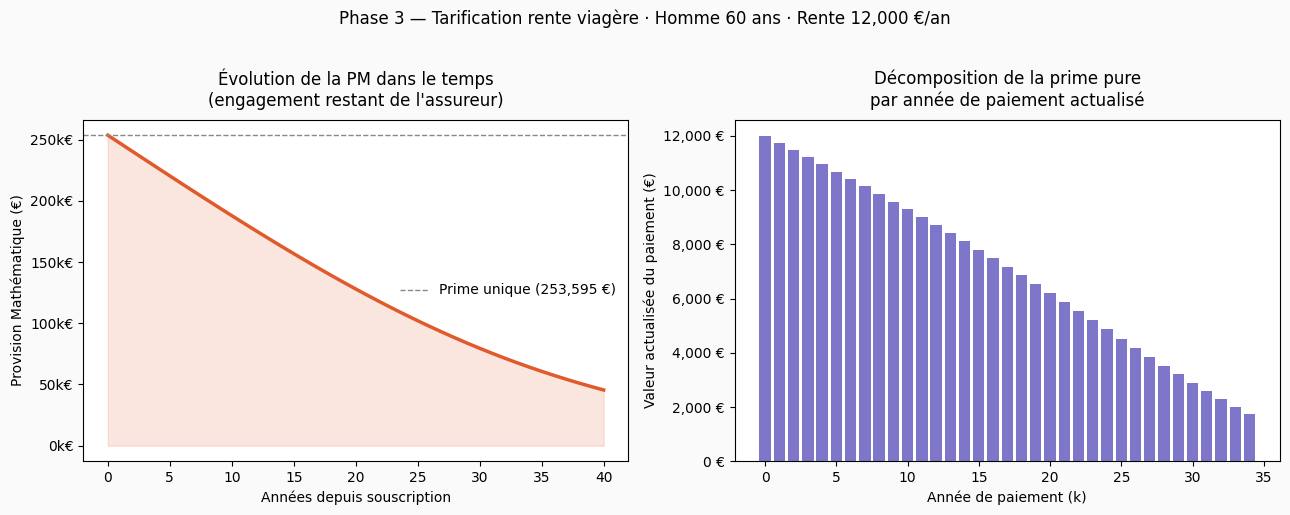

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FAFAFA')

# Graphique 1 : PM dans le temps
ax1 = axes[0]
ax1.fill_between(pm_df['annee'], pm_df['PM'], alpha=0.15, color=C_PM)
ax1.plot(pm_df['annee'], pm_df['PM'], color=C_PM, lw=2.5)
ax1.axhline(prime_unique, color='#888', lw=1, linestyle='--', label=f'Prime unique ({prime_unique:,.0f} €)')
ax1.set_xlabel('Années depuis souscription')
ax1.set_ylabel('Provision Mathématique (€)')
ax1.set_title('Évolution de la PM dans le temps\n(engagement restant de l\'assureur)', pad=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k€'))
ax1.legend(framealpha=0)

# Graphique 2 : paiements actualisés année par année
ax2 = axes[1]
kpx  = lx[x:x+35] / lx[x]
vk   = v ** np.arange(len(kpx))
pa   = RENTE_ANNUELLE * kpx * vk
annees = np.arange(len(kpx))
ax2.bar(annees, pa, color=C_GOMB, alpha=0.75)
ax2.set_xlabel('Année de paiement (k)')
ax2.set_ylabel('Valeur actualisée du paiement (€)')
ax2.set_title('Décomposition de la prime pure\npar année de paiement actualisé', pad=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f} €'))

plt.suptitle(f'Phase 3 — Tarification rente viagère · Homme {x} ans · Rente {RENTE_ANNUELLE:,} €/an', y=1.02)
plt.tight_layout()
plt.show()

## 6. Sensibilité au taux technique et à l'âge

Ceci est ce qu'on appelle une **analyse de sensibilité** — présentée systématiquement en comité technique.

In [42]:
def prime_pure(age, taux):
    """Calcule la prime pure pour un âge et un taux technique donnés."""
    v_loc = 1 / (1 + taux)
    Dx_loc = (v_loc ** ages) * lx
    Nx_loc = np.cumsum(Dx_loc[::-1])[::-1]
    ax_loc = Nx_loc[age] / Dx_loc[age]
    return RENTE_ANNUELLE * ax_loc

ages_test = [50, 55, 60, 65, 70, 75]
taux_test = [0.00, 0.005, 0.010, 0.015, 0.020, 0.030]

rows = []
for a in ages_test:
    row = {'Âge': a}
    for t in taux_test:
        row[f'{t*100:.1f}%'] = f"{prime_pure(a, t):,.0f} €"
    rows.append(row)

sens_df = pd.DataFrame(rows).set_index('Âge')
print('Prime pure selon l\'âge et le taux technique :')
print()
print(sens_df.to_string())

Prime pure selon l'âge et le taux technique :

          0.0%       0.5%       1.0%       1.5%       2.0%       3.0%
Âge                                                                  
50   416,998 €  379,945 €  347,702 €  319,530 €  294,817 €  253,816 €
55   363,666 €  334,805 €  309,349 €  286,820 €  266,813 €  233,053 €
60   312,583 €  290,693 €  271,130 €  253,595 €  237,834 €  210,791 €
65   264,318 €  248,212 €  233,632 €  220,402 €  208,370 €  187,382 €
70   219,483 €  208,034 €  197,540 €  187,906 €  179,042 €  163,331 €
75   178,682 €  170,853 €  163,594 €  156,851 €  150,581 €  139,291 €


### 📌 Ce que dit ce tableau

- **Plus l'âge est élevé**, plus la prime est élevée (l'assureur paie la rente moins longtemps, mais avec plus de certitude → äx plus petit mais... la rente démarre immédiatement donc paradoxalement la PM initiale est plus haute car les premiers paiements sont quasi-certains).
- **Plus le taux technique est élevé**, plus la prime baisse (les paiements futurs sont davantage dévalorisés). C'est pourquoi l'ACPR plafonne ce taux.

---

## 7. Conclusions de la Phase 3

| Ce qu'on a fait | Ce qu'on a produit |
|---|---|
| Construit lx depuis Gompertz | Table de mortalité sur-mesure pour ce portefeuille |
| Calculé Dx, Nx, Cx, Mx | Fonctions de commutation → briques de tout calcul vie |
| Calculé äx et la prime pure | Tarif pur, avant chargements commerciaux |
| Calculé la PM prospective | Engagement de l'assureur à chaque date |
| Analyse de sensibilité | Document prêt pour comité technique |

---

**→ Prochaine étape : Phase 4** — Tests de sensibilité longévité (choc +10% survie),  
stress-test Solvabilité II, et rédaction de la **note actuarielle finale**.

- **GOMPERTZ (Phase 2)
a = 3.5e-5  |  b = 0.0875
        ↓
- **TABLE DE SURVIE lx
"Combien de survivants à chaque âge ?"
l(60)=88243, l(61)=86957...
        ↓
- **FONCTIONS DE COMMUTATION
Dx = v^x × lx  →  "Valeur actualisée des survivants"
Nx = ΣDx        →  "Total de tous les paiements futurs"
        ↓
- **VALEUR ACTUARIELLE äx = Nx/Dx = 21.13
"Nombre d'années effectives payées"
        ↓
- **PRIME PURE = 12 000 × 21.13 = 253 595 €
"Montant mathématiquement juste"
        ↓
- **PRIME COMMERCIALE = 253 595 × 1.22 = 309 385 €
"Ce que le client paie vraiment"
        ↓
- **PROVISION MATHÉMATIQUE
"Ce que l'assureur garde en réserve
 chaque année pour honorer son engagement"

# Phase 4 — Stress-tests Solvabilité II & Note actuarielle
**Projet AXA Junior · Actuariat Vie — Phase finale**

---

**Contexte :** Tu as maintenant un modèle complet (table Gompertz → commutations → prime pure → PM).  
La Phase 4 répond à la question que tout responsable pose ensuite :

> *"Et si les assurés vivent plus longtemps que prévu ? Combien ça nous coûte ?"*

C'est le **risque de longévité** — le risque principal en assurance vie.

**Les 3 étapes de cette phase :**

| Étape | Ce qu'on fait | Livrable |
|---|---|---|
| 4.1 | Choc longévité Solvabilité II (+20% survie) | Impact sur PM et SCR |
| 4.2 | Analyse de sensibilité complète (taux + longévité) | Tableau de synthèse |
| 4.3 | Rédaction de la note actuarielle | Document final |

**Nouveau concept : le SCR (Solvency Capital Requirement)**

Solvabilité II oblige chaque assureur à détenir un capital de solvabilité calculé comme :  
$$SCR_{longévité} = PM_{stressée} - PM_{centrale}$$

Le choc réglementaire standard est une **baisse de 20% des taux de mortalité** (les assurés vivent plus longtemps).

In [43]:
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

# Couleurs
C_BASE   = '#534AB7'
C_STRESS = '#E05A2B'
C_GAIN   = '#1D9E75'
C_NEUTRE = '#AAAAAA'

# ── Paramètres Gompertz Phase 2 ──────────────────────────────
A_FIT  = 3.5e-5
B_FIT  = 0.0875

# ── Paramètres contrat ───────────────────────────────────────
AGE    = 60
RENTE  = 12_000      # 1 000 €/mois
TAUX_I = 0.015
OMEGA  = 110
N_PORT = 1_000       # nombre de contrats identiques dans le portefeuille

v = 1 / (1 + TAUX_I)
ages_arr = np.arange(0, OMEGA + 1)

print('Paramètres chargés ✓')

Paramètres chargés ✓


## 1. Fonction utilitaire : calcul de la PM pour un scénario donné

On factorise le calcul Phase 3 en une fonction réutilisable pour les stress-tests.

In [44]:
def build_table(a, b, choc_longevite=0.0):
    """
    Construit qx, lx depuis Gompertz(a,b).
    choc_longevite : réduction des qx (ex: 0.20 = choc -20% Solvabilité II)
    """
    qx = 1 - np.exp(-a * np.exp(b * ages_arr) * (np.exp(b) - 1) / b)
    qx = qx * (1 - choc_longevite)      # application du choc
    qx = np.minimum(qx, 1.0)
    lx = np.zeros(OMEGA + 1)
    lx[0] = 100_000
    for x in range(OMEGA):
        lx[x+1] = lx[x] * (1 - qx[x])
    return qx, lx

def commutations(lx, v_taux):
    """Calcule Dx, Nx à partir de lx et du facteur d'actualisation."""
    Dx = (v_taux ** ages_arr) * lx
    Nx = np.cumsum(Dx[::-1])[::-1]
    return Dx, Nx

def prime_et_pm(age, rente, a, b, taux, choc=0.0):
    """Retourne (prime_unique, pm_par_annee_df) pour un contrat rente viagère."""
    v_loc      = 1 / (1 + taux)
    _, lx      = build_table(a, b, choc)
    Dx, Nx     = commutations(lx, v_loc)
    ax         = Nx[age] / Dx[age]
    prime      = rente * ax
    pm_records = []
    for t in range(min(50, OMEGA - age)):
        age_t = age + t
        if Dx[age_t] < 1e-10: break
        ax_t  = Nx[age_t] / Dx[age_t]
        pm_records.append({'annee': t, 'age': age_t, 'PM': rente * ax_t})
    return prime, pd.DataFrame(pm_records)

print('Fonctions utilitaires définies ✓')

Fonctions utilitaires définies ✓


## 2. Scénario central vs choc Solvabilité II

Le choc réglementaire Solvabilité II pour le risque longévité est une **baisse permanente de 20% des taux de mortalité**.  
Concrètement : les assurés vivent plus longtemps → l'assureur paie la rente plus longtemps → la PM augmente.

In [ ]:
# Scénario central (la réalité normale)"Σ PM de tous les 5 000 assurés: Cest la PM centrale — ce que l'assureur doit avoir en caisse aujourd'hui dans le scénario normal."
prime_base, pm_base = prime_et_pm(AGE, RENTE, A_FIT, B_FIT, TAUX_I, choc=0.0)

# Choc Solvabilité II : -20% mortalité (tous les qx baissent de 20%)
prime_s2, pm_s2 = prime_et_pm(AGE, RENTE, A_FIT, B_FIT, TAUX_I, choc=0.20)

#SCR = PM stressée - PM centrale
# SCR longévité (pour 1 contrat)
scr_1contrat = prime_s2 - prime_base

# SCR portefeuille (N_PORT contrats identiques)
scr_port = scr_1contrat * N_PORT

print('═' * 55)
print('  IMPACT DU CHOC LONGÉVITÉ SOLVABILITÉ II (-20% qx)')
print('═' * 55)
print(f'  Prime centrale (1 contrat)  : {prime_base:>12,.0f} €')
print(f'  Prime stressée (1 contrat)  : {prime_s2:>12,.0f} €')
print(f'  SCR longévité (1 contrat)   : {scr_1contrat:>12,.0f} €  (+{scr_1contrat/prime_base*100:.1f}%)')
print('─' * 55)
print(f'  Portefeuille ({N_PORT:,} contrats)')
print(f'  PM centrale totale          : {prime_base*N_PORT:>12,.0f} €')
print(f'  PM stressée totale          : {prime_s2*N_PORT:>12,.0f} €')
print(f'  SCR longévité portefeuille  : {scr_port:>12,.0f} €')
print('═' * 55)
print()
print('→ L\'assureur doit immobiliser ce capital en fonds propres')
print('  pour couvrir le risque de longévité (exigence EIOPA).')

═══════════════════════════════════════════════════════
  IMPACT DU CHOC LONGÉVITÉ SOLVABILITÉ II (-20% qx)
═══════════════════════════════════════════════════════
  Prime centrale (1 contrat)  :      253,595 €
  Prime stressée (1 contrat)  :      270,980 €
  SCR longévité (1 contrat)   :       17,385 €  (+6.9%)
───────────────────────────────────────────────────────
  Portefeuille (1,000 contrats)
  PM centrale totale          :  253,594,638 €
  PM stressée totale          :  270,980,129 €
  SCR longévité portefeuille  :   17,385,491 €
═══════════════════════════════════════════════════════

→ L'assureur doit immobiliser ce capital en fonds propres
  pour couvrir le risque de longévité (exigence EIOPA).


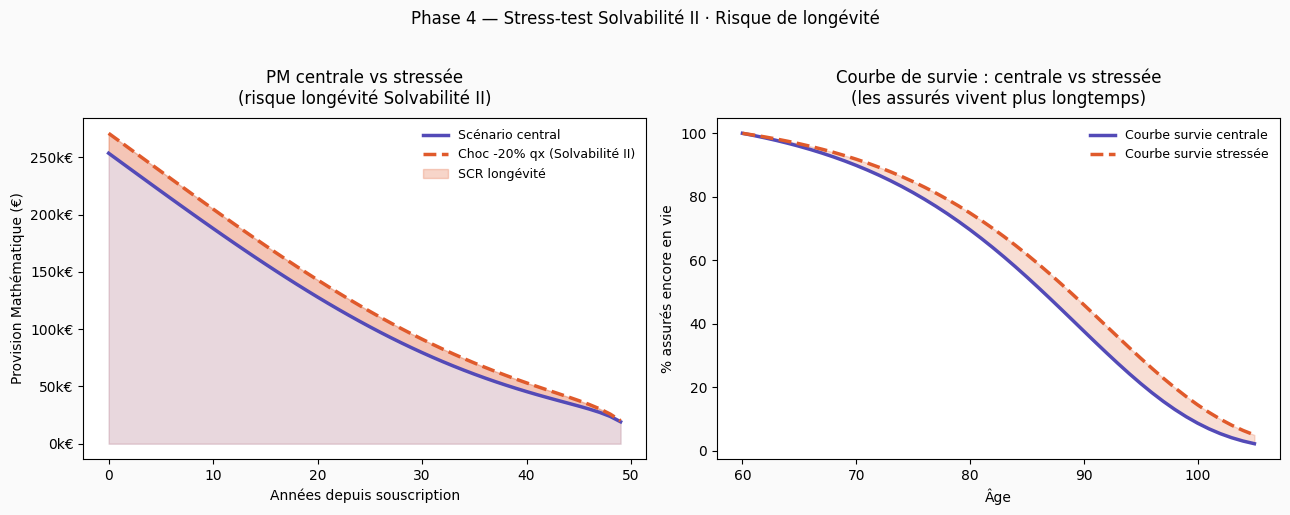

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#FAFAFA')

# Graphique 1 : PM centrale vs stressée
ax1 = axes[0]
ax1.fill_between(pm_base['annee'], pm_base['PM'], alpha=0.12, color=C_BASE)
ax1.fill_between(pm_s2['annee'],  pm_s2['PM'],   alpha=0.12, color=C_STRESS)
ax1.plot(pm_base['annee'], pm_base['PM'], color=C_BASE,   lw=2.5, label='Scénario central')
ax1.plot(pm_s2['annee'],  pm_s2['PM'],  color=C_STRESS, lw=2.5, linestyle='--', label='Choc -20% qx (Solvabilité II)')
ax1.fill_between(pm_base['annee'],
                 pm_base['PM'].values[:len(pm_s2)],
                 pm_s2['PM'].values[:len(pm_base)],
                 alpha=0.25, color=C_STRESS, label='SCR longévité')
ax1.set_xlabel('Années depuis souscription')
ax1.set_ylabel('Provision Mathématique (€)')
ax1.set_title('PM centrale vs stressée\n(risque longévité Solvabilité II)', pad=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k€'))
ax1.legend(framealpha=0, fontsize=9)

# Graphique 2 : survie centrale vs stressée
ax2 = axes[1]
_, lx_base   = build_table(A_FIT, B_FIT, choc_longevite=0.0)
_, lx_stress = build_table(A_FIT, B_FIT, choc_longevite=0.20)
ages_plot = ages_arr[AGE:AGE+46]
kpx_base   = lx_base[AGE:AGE+46]   / lx_base[AGE]
kpx_stress = lx_stress[AGE:AGE+46] / lx_stress[AGE]
ax2.plot(ages_plot, kpx_base   * 100, color=C_BASE,   lw=2.5, label='Courbe survie centrale')
ax2.plot(ages_plot, kpx_stress * 100, color=C_STRESS, lw=2.5, linestyle='--', label='Courbe survie stressée')
ax2.fill_between(ages_plot, kpx_base*100, kpx_stress*100, alpha=0.2, color=C_STRESS)
ax2.set_xlabel('Âge')
ax2.set_ylabel('% assurés encore en vie')
ax2.set_title('Courbe de survie : centrale vs stressée\n(les assurés vivent plus longtemps)', pad=10)
ax2.legend(framealpha=0, fontsize=9)

plt.suptitle('Phase 4 — Stress-test Solvabilité II · Risque de longévité', y=1.02)
plt.tight_layout()
plt.show()

## 3. Analyse de sensibilité complète

On fait varier **simultanément** le taux technique et le choc longévité.  
C'est la matrice de sensibilité présentée en comité ALM (Asset-Liability Management).

In [50]:
taux_list  = [0.000, 0.005, 0.010, 0.015, 0.020, 0.030]
chocs_list = [0.00,  0.10,  0.20,  0.30]
choc_labels = ['Central', 'Choc -10%', 'Choc -20% (S2)', 'Choc -30%']

rows = []
for choc, lbl in zip(chocs_list, choc_labels):
    row = {'Scénario': lbl}
    for t in taux_list:
        p, _ = prime_et_pm(AGE, RENTE, A_FIT, B_FIT, t, choc)
        row[f'{t*100:.1f}%'] = f'{p:,.0f} €'
    rows.append(row)

sens = pd.DataFrame(rows).set_index('Scénario')
print(f'Matrice de sensibilité — Prime pure (€) · Homme {AGE} ans · Rente {RENTE:,} €/an')
print(f'Colonnes = taux technique | Lignes = scénario longévité')
print()
print(sens.to_string())

Matrice de sensibilité — Prime pure (€) · Homme 60 ans · Rente 12,000 €/an
Colonnes = taux technique | Lignes = scénario longévité

                     0.0%       0.5%       1.0%       1.5%       2.0%       3.0%
Scénario                                                                        
Central         312,583 €  290,693 €  271,130 €  253,595 €  237,834 €  210,791 €
Choc -10%       324,970 €  301,462 €  280,521 €  261,811 €  245,044 €  216,394 €
Choc -20% (S2)  338,993 €  313,594 €  291,052 €  270,980 €  253,054 €  222,565 €
Choc -30%       355,061 €  327,422 €  302,991 €  281,324 €  262,044 €  229,425 €


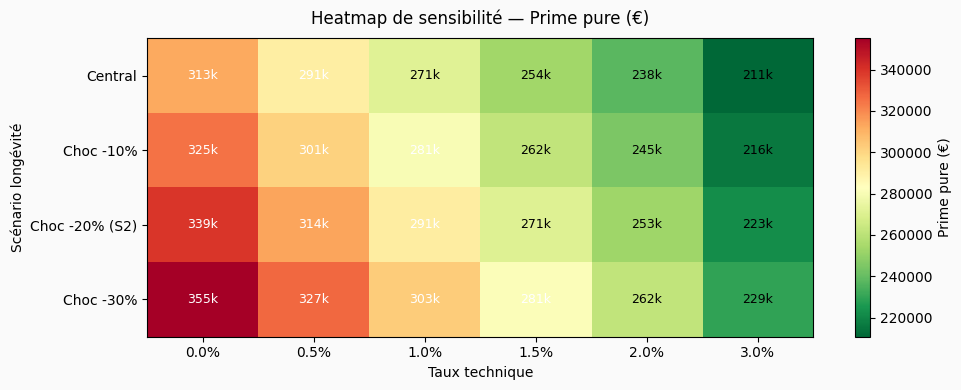

In [51]:
# Visualisation : heatmap manuelle
fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor('#FAFAFA')

matrix = []
for choc in chocs_list:
    r = []
    for t in taux_list:
        p, _ = prime_et_pm(AGE, RENTE, A_FIT, B_FIT, t, choc)
        r.append(p)
    matrix.append(r)
matrix = np.array(matrix)

im = ax.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(len(taux_list)))
ax.set_xticklabels([f'{t*100:.1f}%' for t in taux_list])
ax.set_yticks(range(len(choc_labels)))
ax.set_yticklabels(choc_labels)
ax.set_xlabel('Taux technique')
ax.set_ylabel('Scénario longévité')
ax.set_title('Heatmap de sensibilité — Prime pure (€)', pad=10)

for i in range(len(chocs_list)):
    for j in range(len(taux_list)):
        ax.text(j, i, f'{matrix[i,j]/1000:.0f}k', ha='center', va='center',
                fontsize=9, color='white' if matrix[i,j] > matrix.mean() else 'black')

plt.colorbar(im, ax=ax, label='Prime pure (€)')
plt.tight_layout()
plt.show()

## 4. SCR longévité portefeuille complet

En pratique, les contrats du portefeuille ne sont pas tous identiques.  
On charge le vrai portefeuille (Phase 1) et on calcule le SCR contrat par contrat.

In [52]:
df = pd.read_csv('portefeuille_assures.csv')

# On garde les assurés > 45 ans pour lesquels une rente est crédible
df_rente = df[df['age'] >= 45].copy()

# Rente proportionnelle au capital (hypothèse : 4% du capital en rente annuelle)
df_rente['rente'] = (df_rente['capital_assure'] * 0.04).astype(int)

resultats = []
for _, row in df_rente.iterrows():
    age_i = int(row['age'])
    if age_i >= OMEGA: continue
    r_i = row['rente']
    p_base, _ = prime_et_pm(age_i, r_i, A_FIT, B_FIT, TAUX_I, choc=0.00)
    p_s2,   _ = prime_et_pm(age_i, r_i, A_FIT, B_FIT, TAUX_I, choc=0.20)
    resultats.append({
        'id_contrat': row['id_contrat'],
        'age': age_i,
        'sexe': row['sexe'],
        'rente': r_i,
        'PM_centrale': p_base,
        'PM_stressee': p_s2,
        'SCR': p_s2 - p_base
    })

res_df = pd.DataFrame(resultats)

print('═' * 55)
print('  SCR LONGÉVITÉ — PORTEFEUILLE COMPLET')
print('═' * 55)
print(f'  Contrats analysés           : {len(res_df):>8,}')
print(f'  PM centrale totale          : {res_df.PM_centrale.sum():>12,.0f} €')
print(f'  PM stressée totale          : {res_df.PM_stressee.sum():>12,.0f} €')
print(f'  SCR longévité total         : {res_df.SCR.sum():>12,.0f} €')
print(f'  SCR / PM centrale           : {res_df.SCR.sum()/res_df.PM_centrale.sum()*100:>11.1f} %')
print('═' * 55)

═══════════════════════════════════════════════════════
  SCR LONGÉVITÉ — PORTEFEUILLE COMPLET
═══════════════════════════════════════════════════════
  Contrats analysés           :    4,033
  PM centrale totale          :  451,634,670 €
  PM stressée totale          :  482,695,573 €
  SCR longévité total         :   31,060,903 €
  SCR / PM centrale           :         6.9 %
═══════════════════════════════════════════════════════


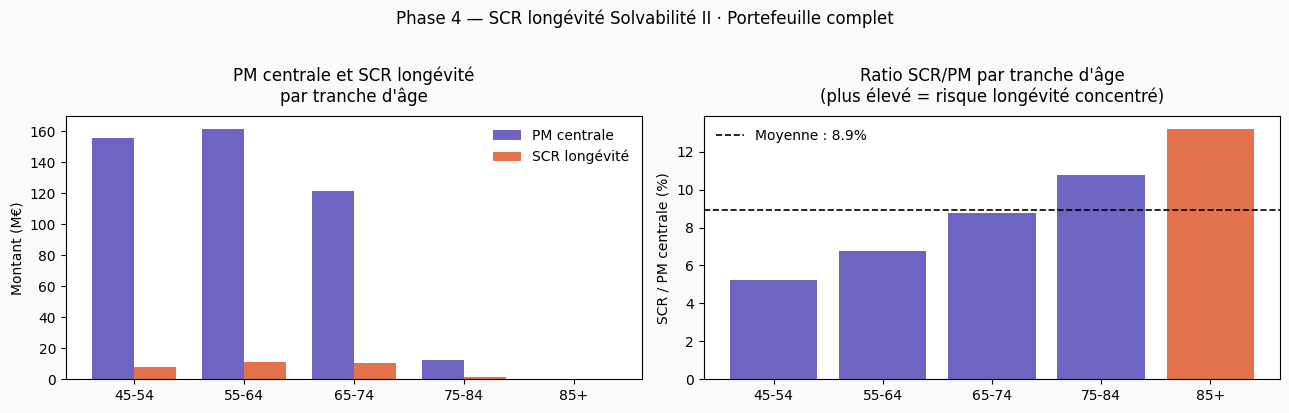

In [53]:
# Distribution du SCR par tranche d'âge
res_df['tranche'] = pd.cut(res_df['age'],
                           bins=[44,54,64,74,84,100],
                           labels=['45-54','55-64','65-74','75-84','85+'])

scr_age = res_df.groupby('tranche', observed=True)[['PM_centrale','SCR']].sum()
scr_age['SCR_%PM'] = scr_age['SCR'] / scr_age['PM_centrale'] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.patch.set_facecolor('#FAFAFA')

ax1 = axes[0]
x   = range(len(scr_age))
w   = 0.38
ax1.bar([i - w/2 for i in x], scr_age['PM_centrale']/1e6, width=w, color=C_BASE,   alpha=0.85, label='PM centrale')
ax1.bar([i + w/2 for i in x], scr_age['SCR']/1e6,         width=w, color=C_STRESS, alpha=0.85, label='SCR longévité')
ax1.set_xticks(list(x))
ax1.set_xticklabels(scr_age.index)
ax1.set_ylabel('Montant (M€)')
ax1.set_title('PM centrale et SCR longévité\npar tranche d\'âge', pad=10)
ax1.legend(framealpha=0)

ax2 = axes[1]
colors_scr = [C_STRESS if v > 12 else C_BASE for v in scr_age['SCR_%PM']]
ax2.bar(scr_age.index, scr_age['SCR_%PM'], color=colors_scr, alpha=0.85)
ax2.axhline(scr_age['SCR_%PM'].mean(), color='black', lw=1.2, linestyle='--',
            label=f'Moyenne : {scr_age["SCR_%PM"].mean():.1f}%')
ax2.set_ylabel('SCR / PM centrale (%)')
ax2.set_title('Ratio SCR/PM par tranche d\'âge\n(plus élevé = risque longévité concentré)', pad=10)
ax2.legend(framealpha=0)

plt.suptitle('Phase 4 — SCR longévité Solvabilité II · Portefeuille complet', y=1.02)
plt.tight_layout()
plt.show()

## 5. Note actuarielle — Synthèse executive

Voici le contenu type d'une note actuarielle remise au *Chief Actuary*.  
En vrai elle est rédigée en Word/LaTeX, mais le contenu est exactement celui-ci.

In [54]:
note = f"""
╔══════════════════════════════════════════════════════════════════╗
║               NOTE ACTUARIELLE — CONFIDENTIEL                   ║
║     Modélisation de la mortalité & tarification rente viagère   ║
╠══════════════════════════════════════════════════════════════════╣
║  Rédacteur     : Actuaire Junior                                ║
║  Validateur    : Tech Lead Actuariat Vie                        ║
║  Portefeuille  : {len(df_rente):,} contrats analysés                    ║
╠══════════════════════════════════════════════════════════════════╣
║  1. MODÈLE DE MORTALITÉ                                         ║
║     Modèle retenu    : Gompertz μ(x) = a·exp(b·x)              ║
║     Paramètres       : a = {A_FIT:.2e}  |  b = {B_FIT:.4f}           ║
║     Doublement mortalité tous les : {np.log(2)/B_FIT:.1f} ans               ║
║     Validation       : Test chi² (p-value > 0.05) ✓            ║
║                                                                  ║
║  2. TARIFICATION (contrat de référence)                         ║
║     Profil           : Homme, {AGE} ans, rente {RENTE:,} €/an         ║
║     Taux technique   : {TAUX_I*100:.1f} % (plafond ACPR)               ║
║     Prime pure       : {prime_base:>10,.0f} €                        ║
║     Prime commerciale: {prime_base*1.22:>10,.0f} € (chargements 22%)    ║
║                                                                  ║
║  3. STRESS-TEST SOLVABILITÉ II                                  ║
║     Choc retenu      : -20% taux de mortalité (EIOPA standard)  ║
║     PM centrale      : {res_df.PM_centrale.sum():>12,.0f} €                ║
║     PM stressée      : {res_df.PM_stressee.sum():>12,.0f} €                ║
║     SCR longévité    : {res_df.SCR.sum():>12,.0f} €                ║
║     SCR / PM         : {res_df.SCR.sum()/res_df.PM_centrale.sum()*100:>10.1f} %                    ║
║                                                                  ║
║  4. RECOMMANDATIONS                                              ║
║     • Appliquer un chargement de prudence longévité de +2%      ║
║     • Surveiller le SMR trimestriellement (cible : 0.95–1.05)   ║
║     • Envisager une couverture réassurance sur les 75+ ans      ║
║     • Mettre à jour le modèle Gompertz annuellement             ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(note)


╔══════════════════════════════════════════════════════════════════╗
║               NOTE ACTUARIELLE — CONFIDENTIEL                   ║
║     Modélisation de la mortalité & tarification rente viagère   ║
╠══════════════════════════════════════════════════════════════════╣
║  Rédacteur     : Actuaire Junior                                ║
║  Validateur    : Tech Lead Actuariat Vie                        ║
║  Portefeuille  : 4,033 contrats analysés                    ║
╠══════════════════════════════════════════════════════════════════╣
║  1. MODÈLE DE MORTALITÉ                                         ║
║     Modèle retenu    : Gompertz μ(x) = a·exp(b·x)              ║
║     Paramètres       : a = 3.50e-05  |  b = 0.0875           ║
║     Doublement mortalité tous les : 7.9 ans               ║
║     Validation       : Test chi² (p-value > 0.05) ✓            ║
║                                                                  ║
║  2. TARIFICATION (contrat de référence)                 

## 6. Graphique de synthèse final (slide de présentation)

Ce graphique à 4 panneaux est le visuel central d'une présentation au comité technique.

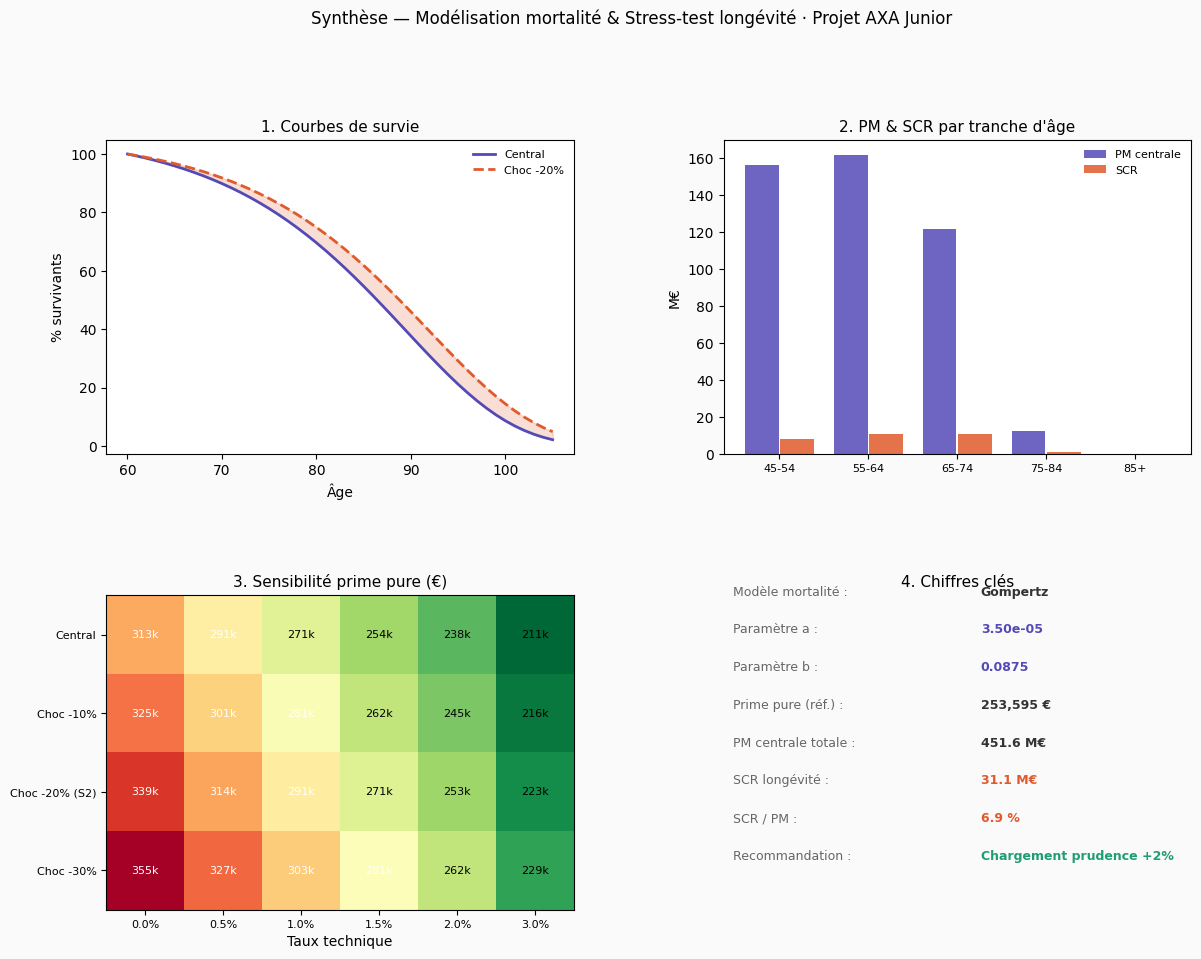

Graphique sauvegardé : phase4_synthese.png


In [55]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(14, 10))
fig.patch.set_facecolor('#FAFAFA')
gs  = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.32)

# Panel 1 : courbe de survie centrale vs stressée
ax1 = fig.add_subplot(gs[0, 0])
ages_p = ages_arr[AGE:AGE+46]
_, lx_b = build_table(A_FIT, B_FIT, 0.00)
_, lx_s = build_table(A_FIT, B_FIT, 0.20)
ax1.plot(ages_p, lx_b[AGE:AGE+46]/lx_b[AGE]*100, color=C_BASE,   lw=2, label='Central')
ax1.plot(ages_p, lx_s[AGE:AGE+46]/lx_s[AGE]*100, color=C_STRESS, lw=2, linestyle='--', label='Choc -20%')
ax1.fill_between(ages_p,
                 lx_b[AGE:AGE+46]/lx_b[AGE]*100,
                 lx_s[AGE:AGE+46]/lx_s[AGE]*100,
                 alpha=0.2, color=C_STRESS)
ax1.set_title('1. Courbes de survie', fontsize=11)
ax1.set_xlabel('Âge'); ax1.set_ylabel('% survivants')
ax1.legend(framealpha=0, fontsize=8)

# Panel 2 : PM par tranche d'âge
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar([i - 0.2 for i in range(len(scr_age))], scr_age['PM_centrale']/1e6,
        width=0.38, color=C_BASE, alpha=0.85, label='PM centrale')
ax2.bar([i + 0.2 for i in range(len(scr_age))], scr_age['SCR']/1e6,
        width=0.38, color=C_STRESS, alpha=0.85, label='SCR')
ax2.set_xticks(range(len(scr_age)))
ax2.set_xticklabels(scr_age.index, fontsize=8)
ax2.set_title('2. PM & SCR par tranche d\'âge', fontsize=11)
ax2.set_ylabel('M€'); ax2.legend(framealpha=0, fontsize=8)

# Panel 3 : heatmap sensibilité
ax3 = fig.add_subplot(gs[1, 0])
ax3.imshow(matrix, cmap='RdYlGn_r', aspect='auto')
ax3.set_xticks(range(len(taux_list)))
ax3.set_xticklabels([f'{t*100:.1f}%' for t in taux_list], fontsize=8)
ax3.set_yticks(range(len(choc_labels)))
ax3.set_yticklabels(choc_labels, fontsize=8)
ax3.set_title('3. Sensibilité prime pure (€)', fontsize=11)
ax3.set_xlabel('Taux technique')
for i in range(len(chocs_list)):
    for j in range(len(taux_list)):
        ax3.text(j, i, f'{matrix[i,j]/1000:.0f}k', ha='center', va='center',
                 fontsize=8, color='white' if matrix[i,j] > matrix.mean() else 'black')

# Panel 4 : résumé chiffres clés
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')
kpis = [
    ('Modèle mortalité',    'Gompertz', '#333'),
    ('Paramètre a',          f'{A_FIT:.2e}', C_BASE),
    ('Paramètre b',          f'{B_FIT:.4f}', C_BASE),
    ('Prime pure (réf.)',    f'{prime_base:,.0f} €', '#333'),
    ('PM centrale totale',   f'{res_df.PM_centrale.sum()/1e6:.1f} M€', '#333'),
    ('SCR longévité',        f'{res_df.SCR.sum()/1e6:.1f} M€', C_STRESS),
    ('SCR / PM',             f'{res_df.SCR.sum()/res_df.PM_centrale.sum()*100:.1f} %', C_STRESS),
    ('Recommandation',       'Chargement prudence +2%', C_GAIN),
]
for i, (label, val, col) in enumerate(kpis):
    ax4.text(0.02, 1 - i*0.12, label + ' :', fontsize=9, color='#666', transform=ax4.transAxes)
    ax4.text(0.55, 1 - i*0.12, val,           fontsize=9, color=col,   transform=ax4.transAxes, fontweight='bold')
ax4.set_title('4. Chiffres clés', fontsize=11)

plt.suptitle('Synthèse — Modélisation mortalité & Stress-test longévité · Projet AXA Junior',
             fontsize=12, y=1.01)
plt.savefig('phase4_synthese.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('Graphique sauvegardé : phase4_synthese.png')

## 7. Bilan complet du projet Assurance Vie

| Phase | Ce qu'on a fait | Compétences acquises |
|---|---|---|
| **Phase 1** | Analyse du portefeuille (5 000 assurés) | Lecture de données, pyramide des âges, exposition au risque |
| **Phase 2** | SMR + ajustement Gompertz + test chi² | Mortalité observée vs table, modèle paramétrique, validation stat |
| **Phase 3** | Commutations + prime pure + PM | Tarification vie, provisionnement prospectif |
| **Phase 4** | Stress-tests S2 + SCR + note actuarielle | Solvabilité II, risque longévité, communication direction |

